<a href="https://colab.research.google.com/github/mteuslms/AI-ML-projects/blob/main/Computer_Vision/imageSemanticSegmentation_revised_2_14_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Semantic Segmentation


In this colab, we'll experience image semantic segmentation via the CamVid dataset. The CamVid dataset is a relatively small dataset containing images of street scenes, with pixel-level annotations for 32 semantic classes.

We'll use the U-Net architecture with a pretrained ResNet-34 "backbone" to perform the segmentation. For more information regarding ResNet-34, please refer to https://blog.roboflow.com/custom-resnet34-classification-model/



In [ ]:
# import necessary libraries
from PIL import Image
import torch
from torch.utils.data import DataLoader

from fastai.vision.all import *

import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder


**Task 1**: write code to check if cuda GPU is available

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# The code below retrieve the image dataset. Codes given.
# After executing the codes, the images are at
# /root/.fastai/data/camvid_tiny/images/
# and the labels are at /root/.fastai/data/camvid_tiny/labels
# You can use the command '!ls' to take a look at the images and labels
path = untar_data(URLs.CAMVID_TINY)
print(path)
codes = np.loadtxt(path/'codes.txt', dtype=str)

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:01&lt;00:00]</div>

/root/.fastai/data/camvid_tiny


(96, 128)


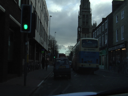

In [ ]:
img = Image.open(path/'images'/'0001TP_006750.png')
from IPython.display import display
print(img.shape)
display(img)

In [ ]:
# The codes below constructs a SegmentationDataLoaders.
# For information regarding SegmentationDataLoaders, please refer to
# https://docs.fast.ai/vision.data.html
# Codes are given
def get_y_fn(x):
    return path/'labels'/f'{x.stem}_P{x.suffix}'

dls = SegmentationDataLoaders.from_label_func(
    path,
    get_image_files(path/"images"),
    get_y_fn,
    codes=codes,
    bs=8,
    item_tfms=Resize(460),
    batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)]
)

Create a learner (model) based on resnet34.
.to_fp16() is to request single digit precision so as to save time.
For information regarding unet_learner, please refer to https://docs.fast.ai/vision.learner.html#unet_learner

In [ ]:
# Codes are given
learn = unet_learner(dls, resnet34, metrics=Dice()).to_fp16()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 229MB/s]


The model can be trained by two ways.

**Way 1**: Use learn.fit(). Since we do not want to update all the resnet34 model parameters, we need to call learn.freeze() before learn.fit().
```
learn.freeze()
learn.fit(2)
```
Here, we freeze all the parameters of the 34 layers, then allow the last two layers to be updated.

**Way 2**:  Use learn.fine_tune(). Example:
```
learn.fine_tune(4, base_lr=0.002, freeze_epochs=2), where the number of epochs is 4, learning rate = 0.002

```
For more information regarding learn.fine_tune(), please refer to https://docs.fast.ai/callback.schedule.html

Note, if you are not using GPU, you will find it very slow. Better to use GPU!

To make it faster, you can revise the code to be:

```
learn = unet_learner(dls, resnet34, metrics=Dice(), wd=0.01).to_fp16()
```

In [ ]:
learn.fine_tune(4, base_lr=0.005, freeze_epochs=2)

epoch,train_loss,valid_loss,dice,time
0,1.153618,1.006255,15.505977,00:08
1,1.209471,1.302621,15.364719,00:08


epoch,train_loss,valid_loss,dice,time
0,1.269513,1.252512,15.021342,00:08
1,1.170006,0.941265,15.422327,00:08
2,1.083915,0.854854,16.969851,00:08
3,1.018343,0.850055,16.038241,00:08


As an alternative to `fine_tune()`, I will now try `learn.freeze()` followed by `learn.fit(2)` to train the model, as suggested in the notebook.

In [ ]:
!pip install --upgrade fastprogress
learn.freeze()
learn.fit(4)

epoch,train_loss,valid_loss,dice,time
0,1.047848,0.931979,16.227738,00:08
1,0.988439,0.830188,17.410841,00:08
2,0.935304,0.826766,16.269114,00:08
3,0.907428,0.757216,17.429824,00:08


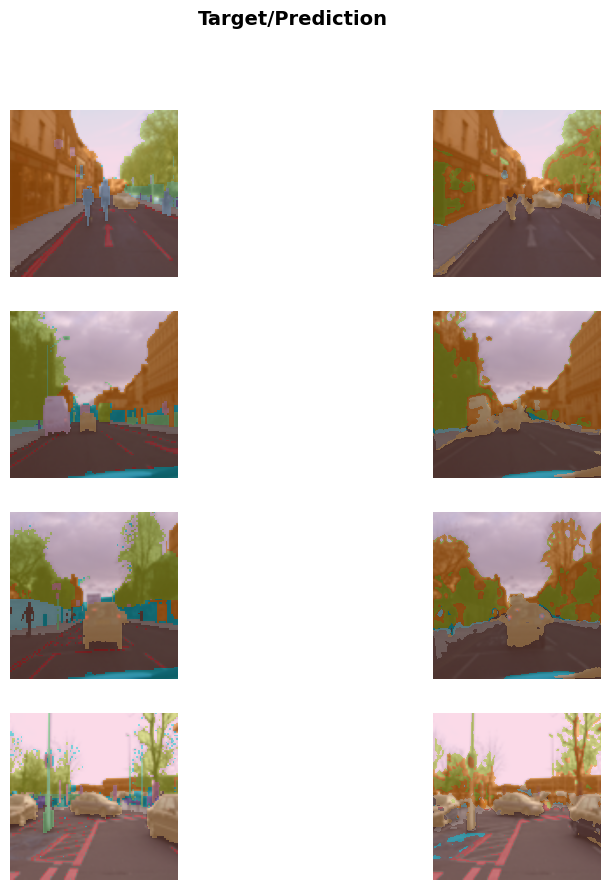

In [ ]:
# Codes are given
# Let's visualize our results.
# Pay close attention to the segmentation results.
# Remember that segmentation is to mask certain pixels
learn.show_results(max_n=4, figsize=(10, 10))

In [ ]:
# Now download an image prepared for you
url = 'https://drive.google.com/file/d/1Tgj9W24rMPQZWUTF257geuhn9JOXS5dO/view?usp=drive_link'
!gdown --id 1Tgj9W24rMPQZWUTF257geuhn9JOXS5dO -O /content/sample_data/streetImage-original.png

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Tgj9W24rMPQZWUTF257geuhn9JOXS5dO
To: /content/sample_data/streetImage-original.png
100% 576k/576k [00:00<00:00, 136MB/s]


(96, 128)


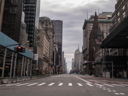

In [ ]:
# Work on this image. It took me hours to make this work.
# Still, the performance is not good.
import PIL
image_path = '/content/nystreet.jpg'
img = PIL.Image.open(image_path)
# convert the color image to black white
# img = img.convert("1") # This worked, but my friend David Liu found out that
# img = img.convert("RGB") works better
img = img.convert("RGB")
img = img.resize((128, 96))
img.show() # must call this first, otherwise it won't work
print(img.shape)


display(img)


<Axes: >

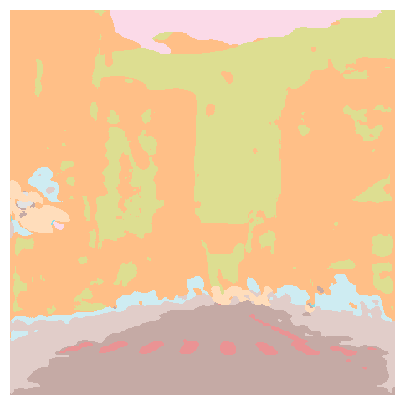

In [ ]:
pred_mask, _, _ = learn.predict(img)
pred_mask.show(figsize=(5, 5))

#Task

Your task is to


1.   Find or take your own street image, save it as .png
2.   Share your image through Google Drive
3.   Download your image into sample_data/
4.   Use the existing resnet34 model to conduct semantic segmentation on your image.
5.   Display your result

